## Import necessary libraries

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import  CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from scipy.stats import pearsonr

import re
from collections import Counter
from IPython.display import display
import plotly.graph_objects as go

import math

import time # To check notebook run time

import os
import json
import requests
from tqdm.auto import tqdm

TMDB_API_KEY = "0a21f12df0bb20ab4e7bac8719d9891e"
TMDB_BASE_URL = "https://api.themoviedb.org/3"

## Check Runtime Of Notebook

In [2]:
start_time = time.time()

## Load the Full dataset

In [3]:
df = pd.read_csv("Netflix_Streaming_Data.csv") # Read the csv file to DataFrame

## Target Column - Ratings

In [4]:
initial_count = len(df)
print(f"The data initialy has {initial_count} rows")

The data initialy has 8807 rows


In [5]:
target = df.rating
print(f"We initially have the following ratings: {list(target.unique())}")
print(f'We have {target.nunique()} values for this column')

We initially have the following ratings: ['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R', 'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan, 'TV-Y7-FV', 'UR']
We have 17 values for this column


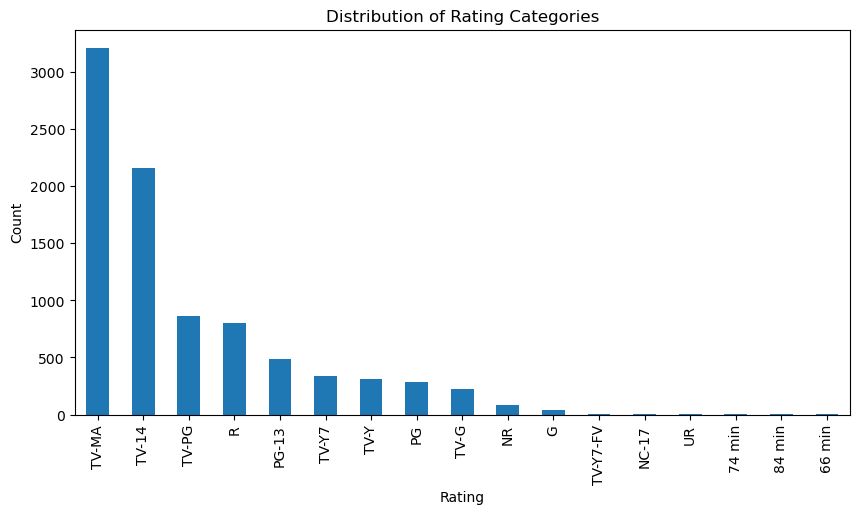

In [6]:
# Distribution plot of all 17 Rating categories
df['rating'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Distribution of Rating Categories")
plt.ylabel("Count")
plt.xlabel("Rating")
plt.show()

In [7]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

There are three strange values that are NOT ratings, but appear to be durations accidentally placed into the rating column: 74 min, 84 min, 66 min. We decided to remove them, as they are a small amount of the total data (only 3 obseravations).

In [8]:
# Remove incorrect rating entries 
invalid_values = ['74 min', '84 min', '66 min']
df = df[~df['rating'].isin(invalid_values)]

# Check updated unique rating counts
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [9]:
# Check for missing values in Rating column
missing_rating = df["rating"].isna().sum()
print(f"There are {missing_rating} missing values in the rating column.")

There are 4 missing values in the rating column.


In [10]:
# Drop rows where rating is missing
df = df.dropna(subset=['rating'])

# Check updated unique rating counts
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [11]:
# Remove rows which are declared as none rated categories - UR, NR
none_rated_categories = ['UR', 'NR']
df= df[~df['rating'].isin(none_rated_categories)]

# Check updated unique rating counts
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
G             41
TV-Y7-FV       6
NC-17          3
Name: count, dtype: int64

In total, the dataset initially contained 8,807 observations, out of which:
   - 3 observations were removed due to invalid rating values
   - 4 observations were removed due to missing (NaN) rating values
   - 83 observations were removed due to non-rated categories (UR, NR)

This results in a total of 90 removed observations, which corresponds to:

                                90/8807≈0.0102=1.02%


In total, we removed 90 observations, which is approximately 1.02% of the dataset, ensuring that the target variable includes only valid rating categories.

In order to have meaningful categories for classification we will group together the different rating categories into 3 semantically similar classes:
| **Group Name** | **Ratings Included** | Meaning                                   |
| -------------- | -------------------- | ----------------------------------------- |
| **Family & Kids**       | TV-Y, TV-Y7, TV-G, TV-Y7-FV, G, TV-PG | Content suitable for all ages and for young children                |
| **Teen**       | TV-14, PG, PG-13                | Designed for teens, some mature themes    |
| **Adult**      | R, TV-MA, NC-17        | Mature audiences                          |

In [12]:
rating_map = {
    'TV-Y': 'Family & Kids',
    'TV-Y7': 'Family & Kids',
    'TV-G': 'Family & Kids',
    'TV-Y7-FV': 'Family & Kids',
    'G': 'Family & Kids',
    'TV-PG': 'Family & Kids',
    
    'TV-14': 'Teen',
    'PG': 'Teen',
    'PG-13': 'Teen',
    
    'R': 'Adult',
    'TV-MA': 'Adult',
    'NC-17': 'Adult'
}

df['rating_grouped'] = df['rating'].map(rating_map)

# See count distribution after grouping
df['rating_grouped'].value_counts()

rating_grouped
Adult            4009
Teen             2937
Family & Kids    1771
Name: count, dtype: int64

In [13]:
# Drop the original "Rating" column
netflix_data = df.drop(columns=['rating'])

For classification we need to encode the group labels into numeric classes, we will map the 3 groups as follows:

| Group  | Class ID |
| ------ | -------- |
| Family & Kids  | 0        |
| Teen   | 1        |
| Adult  | 2        |

In [14]:
label_map = {'Family & Kids': 0, 'Teen': 1, 'Adult': 2}
netflix_data['rating_label'] = netflix_data['rating_grouped'].map(label_map)

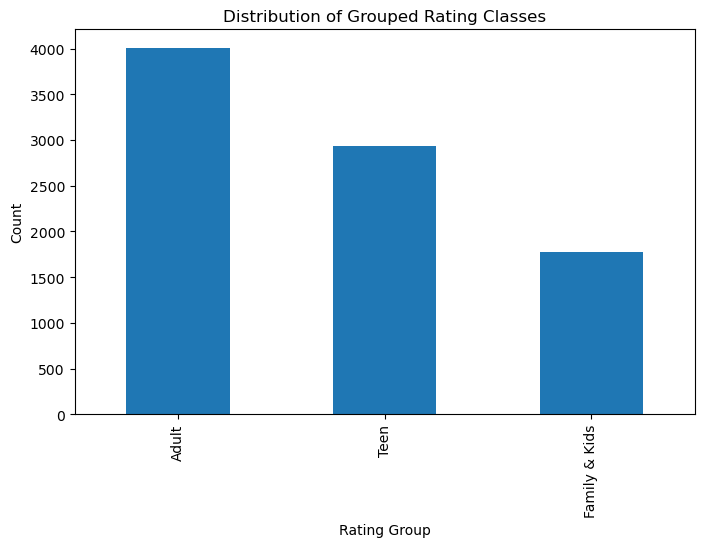

In [15]:
# Plot the distibution of the grouped ratings 
netflix_data['rating_grouped'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Distribution of Grouped Rating Classes")
plt.xlabel("Rating Group")
plt.ylabel("Count")
plt.show()

## Split the Full Dataset to Train & Test

In [16]:
# We will use the numeric label as target
target = 'rating_label'

# Drop unused columns that won't help in modeling
X = netflix_data.drop(columns=[target])  # Features
y = netflix_data[target]                 # Target


# Split full dataset to train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify ensures class balance
)

# Confirm the split
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTarget distribution in train:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTarget distribution in test:")
print(y_test.value_counts(normalize=True) * 100)

Train shape: (6973, 12)
Test shape: (1744, 12)

Target distribution in train:
rating_label
2    45.991682
1    33.687079
0    20.321239
Name: proportion, dtype: float64

Target distribution in test:
rating_label
2    45.986239
1    33.715596
0    20.298165
Name: proportion, dtype: float64


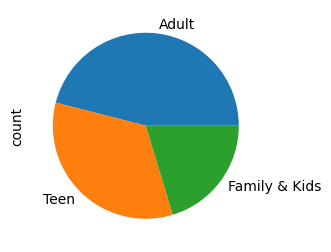

In [17]:
# Plot the distibution of the grouped ratings 
X_train['rating_grouped'].value_counts().plot(kind='pie', figsize=(3,5))
plt.show()

In [18]:
"""
# Save the train and test data in different csv's per project request in submission

X_train.to_csv("X_train.csv", index=True)
X_test.to_csv("X_test.csv", index=True)
y_train.to_csv("y_train.csv", index=True)
y_test.to_csv("y_test.csv", index=True)
"""

'\n# Save the train and test data in different csv\'s per project request in submission\n\nX_train.to_csv("X_train.csv", index=True)\nX_test.to_csv("X_test.csv", index=True)\ny_train.to_csv("y_train.csv", index=True)\ny_test.to_csv("y_test.csv", index=True)\n'

## Initial introduction and inspection

In [19]:
X_train.head() # 5 rows is the default for head() so you can either write down 5 or not and will be the same

,show_id,type,title,director,cast,country,date_added,release_year,duration,listed_in,description,rating_grouped
6222,s6223,Movie,Balto 3: Wings of Change,Phil Weinstein,"Maurice LaMarche, Sean Astin, Keith Carradine,...",United States,"April 1, 2018",2004,78 min,Children & Family Movies,A pilot challenges Balto's son Kodi and his sl...,Family & Kids
1373,s1374,TV Show,50M2,NaN,"Engin Öztürk, Kürşat Alnıaçık, Cengiz Bozkurt,...",Turkey,"January 27, 2021",2021,1 Season,"International TV Shows, TV Dramas, TV Thrillers","Seeking to uncover the truth about his past, a...",Adult
6994,s6995,Movie,Hope Springs Eternal,Jack C. Newell,"Mia Rose Frampton, Beth Lacke, Stony Blyden, J...",United States,"November 8, 2018",2018,79 min,Dramas,When a teen with terminal cancer miraculously ...,Teen
8144,s8145,Movie,Taal,Subhash Ghai,"Anil Kapoor, Aishwarya Rai Bachchan, Akshaye K...",India,"March 1, 2018",1999,177 min,"Dramas, International Movies, Music & Musicals",Businessman Manav falls for aspiring singer Ma...,Family & Kids
1409,s1410,Movie,The Vanished,Peter Facinelli,"Thomas Jane, Anne Heche, Jason Patric, John D....",United States,"January 15, 2021",2020,115 min,Thrillers,When their daughter disappears during a family...,Adult


In [20]:
num_rows, num_columns = X_train.shape
# Print the number of rows and columns of the DataFrame
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

# Print the shape of the DataFrame
print(f"Shape of the DataFrame: {X_train.shape}")

Number of rows: 6973
Number of columns: 12
Shape of the DataFrame: (6973, 12)


In [21]:
#Check the data types
print("Column names:")
print(list(X_train.columns)) # This prints only the columns names of the df

print("\nData types of each column:")
print(X_train.dtypes)

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'duration', 'listed_in', 'description', 'rating_grouped']

Data types of each column:
show_id           object
type              object
title             object
director          object
cast              object
country           object
date_added        object
release_year       int64
duration          object
listed_in         object
description       object
rating_grouped    object
dtype: object


### Descriptive statistics

#### Let's explore some basic descriptive statistics of the dataframe.

In [22]:
# Display the summary statistics for each column in the DataFrame, including non-numeric (categorical data) in order to have
# summary statistics for all the columns
summary_statistics_all = X_train.describe(include='all')
summary_statistics_all

,show_id,type,title,director,cast,country,date_added,release_year,duration,listed_in,description,rating_grouped
count,6973,6973,6973,4886,6337,6311,6967,6973.000000,6973,6973,6973,6973
unique,6973,2,6973,3731,6142,625,1635,NaN,209,481,6959,3
top,s6223,Movie,Balto 3: Wings of Change,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",NaN,1 Season,"Dramas, International Movies",This educational series for tiny tots features...,Adult
freq,1,4854,1,18,14,2208,93,NaN,1423,298,2,3207
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.273627,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.649034,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1942.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


#### Summary of initial dataset statistics:

The training dataset contains 6,973 titles, each uniquely identified by show_id and title. The catalog is composed mainly of Movies (≈70%), with TV Shows making up the remainder. Most categorical fields exhibit very high cardinality: for example, director has 3,731 unique names, cast includes over 6,000 unique actors, and listed_in spans 481 genre/category combinations, highlighting the dataset’s large diversity.

The most common values reflect typical patterns in Netflix content: United States is the dominant production country (appearing in 2,208 titles), and many records share frequently occurring genre tags such as Dramas and International Movies. For the rating_grouped target variable, “Adult” is the most common class (3,207 observations), followed by Teen and Family & Kids.

Missingness varies across metadata fields. While type, title, and release_year are fully populated, fields such as director (2,087 missing), cast (636 missing), and country (662 missing) contain gaps, which motivates the enrichment and imputation procedures performed later. The date_added feature is nearly complete, with only 6 missing entries.

The only fully numeric feature, release_year, ranges from 1942 to 2021, with a median year of 2017 and a mean of 2014, indicating that Netflix's catalogue skews toward more recent releases.

Overall, the dataset is rich, diverse, and dominated by long-tail categorical variables typical of entertainment metadata, requiring careful handling of missing data and appropriate feature engineering techniques before modeling.

In [23]:
# General dataset overview
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6973 entries, 6222 to 3501
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   show_id         6973 non-null   object
 1   type            6973 non-null   object
 2   title           6973 non-null   object
 3   director        4886 non-null   object
 4   cast            6337 non-null   object
 5   country         6311 non-null   object
 6   date_added      6967 non-null   object
 7   release_year    6973 non-null   int64 
 8   duration        6973 non-null   object
 9   listed_in       6973 non-null   object
 10  description     6973 non-null   object
 11  rating_grouped  6973 non-null   object
dtypes: int64(1), object(11)
memory usage: 708.2+ KB


#### Summary of Data Frame Information:

The training dataset contains 6,973 records and 12 columns, with nearly all features stored as text (object) except for release_year, which is numeric. Core identifying and descriptive fields—show_id, type, title, duration, listed_in, and description—are fully populated, ensuring complete coverage for fundamental metadata.

Several key enrichment fields exhibit missing values: director has the largest gap with 2,087 missing entries, followed by cast (636 missing) and country (662 missing), confirming that these attributes require targeted imputation or external lookup. Meanwhile, date_added is almost fully complete, missing only 6 values, and the target variable rating_grouped is fully available for all observations.

Overall, the dataset is well-structured with consistent datatypes, dominated by textual features that will require preprocessing techniques such as tokenization, embeddings, and one-hot encoding. Its memory footprint is modest (~708 KB).

In [24]:
X_train.nunique()

show_id           6973
type                 2
title             6973
director          3731
cast              6142
country            625
date_added        1635
release_year        71
duration           209
listed_in          481
description       6959
rating_grouped       3
dtype: int64

#### Unique Values Summary:

The uniqueness profile of the dataset highlights its high diversity across most metadata fields. Core identifiers such as show_id and title contain 6,973 unique values, confirming that each row represents a distinct Netflix entry. Textual fields such as description and cast also show extremely high variability, with 6,959 and 6,142 distinct values respectively, reflecting the rich, unstructured nature of the content.

Contributor-related fields exhibit substantial cardinality as well: director spans 3,731 unique names, and country encompasses 625 unique production origins, emphasizing the global breadth of the catalog. Temporal and categorical attributes are more compact, with 71 unique release years, 209 duration formats, and 481 category combinations in listed_in.

The target variable rating_grouped contains only three distinct classes, aligning well with the simplified classification framework (Family & Kids, Teen, Adult). Overall, the uniqueness distribution underscores the dataset’s complexity, particularly in long-tail categorical and free-text features, which will require thoughtful preprocessing and encoding strategies during modeling.

# Handiling Missing Values 

## Helper Function 

In [25]:
def df_to_plotly_table(
    df,
    title=None,
    max_rows=None,
    decimals=2,
    include_index=True,
    height="auto"
):
    df_disp = df.copy()

    if max_rows is not None:
        df_disp = df_disp.head(max_rows)

    if include_index:
        df_disp = df_disp.reset_index()

        first_col = df_disp.columns[0]
        if str(first_col).lower() == "index":
            df_disp = df_disp.rename(columns={first_col: ""})

    num_cols = df_disp.select_dtypes(include="number").columns
    df_disp[num_cols] = df_disp[num_cols].round(decimals)
    for c in num_cols:
        df_disp[c] = df_disp[c].map(lambda x: f"{x:.{decimals}f}" if x is not None else x)

    if height == "auto":
        height = 120 + len(df_disp) * 24

    fig = go.Figure(data=[go.Table(
        header=dict(values=list(df_disp.columns)),
        cells=dict(values=[df_disp[col] for col in df_disp.columns])
    )])

    fig.update_layout(
        title=title,
        height=height,
        margin=dict(l=8, r=8, t=35 if title else 8, b=8)
    )
    return fig

## Check missing values

In [26]:
# Calculate the total number of missing values per column
missing_counts = X_train.isnull().sum()

# Calculate the proportion of missing values (as a percentage)
missing_proportion = missing_counts / X_train.shape[0]

# Create a new DataFrame with the desired columns
result_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Proportion (%)": round(missing_proportion*100,2)
})

display(result_df)

,Missing Count,Missing Proportion (%)
show_id,0,0.00
type,0,0.00
title,0,0.00
director,2087,29.93
cast,636,9.12
country,662,9.49
date_added,6,0.09
release_year,0,0.00
duration,0,0.00
listed_in,0,0.00


Let's check whether missingness correlates with the label:

In [27]:
missing_by_label = (
    X_train.isna()
    .groupby(X_train["rating_grouped"])
    .mean()
    .T * 100
)

df_to_plotly_table(
    missing_by_label,
    "Percentage of Missing Values by Rating Group"
).show()

### Missing-Value Analysis and Imputation Rationale

Before applying any imputation methods, we examined whether missing values were disproportionately concentrated within specific target classes, as such patterns could introduce unintended bias into the learning process. Although some variation in missingness exists across rating groups, particularly for the director and country attributes, no class is dominated by missing values, and the patterns are not class-exclusive. This indicates that missingness is not driven by the target label and is therefore unlikely to bias model training.

Given that missingness is non-random yet not label-dependent, leveraging external metadata sources (TMDb) represents the most appropriate strategy for recovering true values where possible. For the country attribute, where missingness is evenly distributed and a dominant mode exists, frequency-based imputation preserves the original label distribution without injecting label-specific signal. For director and cast, where missingness persists across all classes, assigning an explicit “Unknown” category allows the model to learn whether missingness itself carries predictive information, while avoiding speculative or noisy imputations.

Overall, the following imputation strategy is conservative, consistent, and label-agnostic, ensuring data completeness while minimizing the risk of information leakage or bias.

Now let's take a look at the rows and the amount of missing values they hold.

In [28]:
# Number of rows with more than 2,3 missing values in their row
thresh_2 = X_train[X_train.isna().sum(axis=1)>=2].shape[0]
thresh_3 = X_train[X_train.isna().sum(axis=1)>=3].shape[0]

print(f"There are {thresh_2} with at least 2 missing values ")
print(f"There are {thresh_3} with at least 3 missing values ")

There are 580 with at least 2 missing values 
There are 76 with at least 3 missing values 


## Helper Functions 

In order to complete these missing values we will use Tmdb API. This API returns a JSON record with type (Movie / TVSeries), name, director(s), actors, release date, description etc.

We will query each title and release_year as many titles exist across different years and using only the title may return the wrong attributes we expect - Using the release year should increases accuracy.

### Helper 1: Cache helpers

Load/save cache - We’ll store cache in a JSON file as to not recall the API for the same title.

In [29]:
def load_cache(cache_path="tmdb_cache.json"):
    if not os.path.exists(cache_path):
        return {}
    try:
        with open(cache_path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        print("⚠️ Warning: Cache file corrupted. Resetting cache.")
        return {}

def save_cache(cache, cache_path="tmdb_cache.json"):
    with open(cache_path, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)

### Helper 2: TMDb search
Find the best matching TMDb ID

In [30]:
def tmdb_search(title, year=None, content_type="Movie"):
    """
    Search TMDb for a given title (and optional year).
    content_type: 'Movie' or 'TV Show' (from 'type' column).
    Returns TMDb ID or None.
    """
    if not TMDB_API_KEY:
        return None
    
    # Choose endpoint based on type
    if str(content_type).lower().startswith("movie"):
        endpoint = f"{TMDB_BASE_URL}/search/movie"
        params = {"api_key": TMDB_API_KEY, "query": title}
        if pd.notna(year):
            params["year"] = int(year)
    else:
        endpoint = f"{TMDB_BASE_URL}/search/tv"
        params = {"api_key": TMDB_API_KEY, "query": title}
        if pd.notna(year):
            params["first_air_date_year"] = int(year)
    
    # First try: with year (if given)
    resp = requests.get(endpoint, params=params, timeout=10)
    if resp.status_code != 200:
        return None
    
    data = resp.json()
    results = data.get("results", [])
    
    # If no results and we used a year filter → retry without year
    if not results and ("year" in params or "first_air_date_year" in params):
        params.pop("year", None)
        params.pop("first_air_date_year", None)
        resp = requests.get(endpoint, params=params, timeout=10)
        if resp.status_code != 200:
            return None
        data = resp.json()
        results = data.get("results", [])
    
    if not results:
        return None
    
    # Simplest: take the first result
    return results[0].get("id")

### Helper 3: TMDb details - extract director, cast, country

We use movie_id or tv_id with append_to_response=credits.

In [31]:
def tmdb_get_details(tmdb_id, content_type="Movie"):
    """
    Given a TMDb ID and content_type, fetch details + credits.
    Returns dict with keys: director, cast, country (strings or None).
    """
    if str(content_type).lower().startswith("movie"):
        endpoint = f"{TMDB_BASE_URL}/movie/{tmdb_id}"
    else:
        endpoint = f"{TMDB_BASE_URL}/tv/{tmdb_id}"
    
    params = {
        "api_key": TMDB_API_KEY,
        "append_to_response": "credits"
    }
    
    resp = requests.get(endpoint, params=params, timeout=10)
    if resp.status_code != 200:
        return None
    
    data = resp.json()
    
    credits = data.get("credits", {})
    crew = credits.get("crew", [])
    cast_list = credits.get("cast", [])
    
    # ----- Director / "creator" -----
    director_name = None
    
    if str(content_type).lower().startswith("movie"):
        # Look for crew job == Director
        for member in crew:
            if member.get("job") == "Director":
                director_name = member.get("name")
                break
    else:
        # TV shows often have 'created_by'
        created_by = data.get("created_by", [])
        if created_by:
            director_name = ", ".join(
                [c["name"] for c in created_by if isinstance(c, dict) and "name" in c]
            )
        else:
            # Fallback: look for a Director-like job in crew
            for member in crew:
                if member.get("job") in ("Director", "Executive Producer", "Series Director"):
                    director_name = member.get("name")
                    break
    
    # ----- Cast -----
    cast_names = [c["name"] for c in cast_list if "name" in c][:10]  # top 10
    cast_str = ", ".join(cast_names) if cast_names else None
    
    # ----- Countries -----
    countries_info = data.get("production_countries", [])
    country_names = [c["name"] for c in countries_info if "name" in c]
    country_str = ", ".join(country_names) if country_names else None
    
    return {
        "director": director_name or None,
        "cast": cast_str,
        "country": country_str
    }


### Helper 4: High-level TMDb query: search + details

In [32]:
def query_tmdb_metadata(title, year, content_type):
    """
    Full TMDb lookup: search by title (+year) → fetch details → extract fields.
    Returns dict or None.
    """
    tmdb_id = tmdb_search(title, year, content_type)
    if not tmdb_id:
        return None
    return tmdb_get_details(tmdb_id, content_type)


### Helper 5: Row-level enrichment using cache

This function takes a row and calls the API only if director/cast/country is missing (retaning cache if need be) and fills in the missing fields

In [33]:
def enrich_row_with_tmdb(row, cache, max_sleep=0.1):
    """
    Enrich a single row with director, cast, country using TMDb + cache.
    Only fills missing values (NaN / empty string).
    """
    needs_director = pd.isna(row["director"]) or row["director"] == ""
    needs_cast = pd.isna(row["cast"]) or row["cast"] == ""
    needs_country = pd.isna(row["country"]) or row["country"] == ""
    
    if not (needs_director or needs_cast or needs_country):
        return row  # nothing to do
    
    title = row["title"]
    year = row["release_year"]
    content_type = row["type"]  # 'Movie' or 'TV Show'
    
    # Build cache key
    cache_key = f"{title}||{year}||{content_type}"
    
    if cache_key in cache:
        info = cache[cache_key]
    else:
        info = query_tmdb_metadata(title, year, content_type)
        cache[cache_key] = info  # even if None, cache the failure
        time.sleep(max_sleep)    # be nice to the API
    
    if not info:
        return row
    
    if needs_director and info.get("director"):
        row["director"] = info["director"]
    if needs_cast and info.get("cast"):
        row["cast"] = info["cast"]
    if needs_country and info.get("country"):
        row["country"] = info["country"]
    
    return row

### Full Function - DataFrame-level enrichment

Main missing values function.
Main pipeline: apply to a whole DataFrame (train or test).
This function:
    
1) Loads cache

2) Finds rows with missing director OR cast OR country

3) Runs enrichment with progress bar

4) Saves cache

5) Returns enriched DataFrame

In [34]:
def enrich_with_tmdb(df, cache_path="tmdb_cache.json", max_requests=None):
    """
    Enrich director, cast, country using TMDb for rows with missing values.
    Uses JSON cache on disk to avoid repeated API calls.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain: 'title', 'release_year', 'type', 'director', 'cast', 'country'
    cache_path : str
        Path to JSON cache file.
    max_requests : int or None
        If set, limit the number of TMDb API calls (for testing or quota control).
    """
    df = df.copy()
    cache = load_cache(cache_path)
    
    mask_missing = df["director"].isna() | df["cast"].isna() | df["country"].isna()
    idx_to_process = df[mask_missing].index
    
    print(f"Rows with at least one missing [director/cast/country]: {len(idx_to_process)}")
    print(f"Cache currently has {len(cache)} entries.")
    
    requests_made = 0
    
    for idx in tqdm(idx_to_process, desc="Enriching with TMDb", disable=True):
        if max_requests is not None and requests_made >= max_requests:
            break
        
        row_before = df.loc[idx]
        needs_director = pd.isna(row_before["director"]) or row_before["director"] == ""
        needs_cast = pd.isna(row_before["cast"]) or row_before["cast"] == ""
        needs_country = pd.isna(row_before["country"]) or row_before["country"] == ""
        
        if not (needs_director or needs_cast or needs_country):
            continue
        
        title = row_before["title"]
        year = row_before["release_year"]
        content_type = row_before["type"]
        cache_key = f"{title}||{year}||{content_type}"
        
        before = len(cache)
        df.loc[idx] = enrich_row_with_tmdb(df.loc[idx], cache)
        after = len(cache)
        
        if after > before:
            requests_made += 1
    
    save_cache(cache, cache_path)
    print(f"Total new TMDb API calls made in this run: {requests_made}")
    
    return df

Apply on train set:

In [35]:
X_train_enriched = enrich_with_tmdb(X_train, cache_path="tmdb_cache.json")

# Check remaining missing values
print(X_train_enriched[['director', 'cast', 'country']].isna().sum())

Rows with at least one missing [director/cast/country]: 2735
Cache currently has 3446 entries.


C:\Users\עידן שכטר\AppData\Local\Temp\ipykernel_50348\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\עידן שכטר\AppData\Local\Temp\ipykernel_50348\2487003707.py:35: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\עידן שכטר\AppData\Local\Temp\ipykernel_50348\2487003707.py:33: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Total new TMDb API calls made in this run: 0
director    619
cast        233
country     183
dtype: int64


| Column   | Before TMDb | After TMDb | Remaining   | Fill Rate |
| -------- | ----------- | ---------- | ----------- | --------- |
| director | 2087        | 619        | 1468 filled | ~70%      |
| cast     | 636         | 233        | 403 filled  | ~63%      |
| country  | 662         | 183        | 479 filled  | ~72%      |


In [36]:
# Number of rows with more than 2,3 missing values in their row
thresh_2 = X_train_enriched[X_train_enriched.isna().sum(axis=1)>=2].shape[0]
thresh_3 = X_train_enriched[X_train_enriched.isna().sum(axis=1)>=3].shape[0]

print(f"There are {thresh_2} with at least 2 missing values ")
print(f"There are {thresh_3} with at least 3 missing values ")

There are 144 with at least 2 missing values 
There are 18 with at least 3 missing values 


In [37]:
# Compare original and enriched rows
changed_rows = []

for idx in X_train.index:
    before = X_train.loc[idx]
    after = X_train_enriched.loc[idx]
    
    # Check if any of the 3 metadata fields differ
    if (
        before['director'] != after['director'] or
        before['cast'] != after['cast'] or
        before['country'] != after['country']
    ):
        changed_rows.append(idx)

# Show how many rows TMDb changed
len(changed_rows)

2735

TMDb doesn't only fill missing data, it also updates or fixes existing data. So the amount of rows changed which is bigger then the amount of filled values makes sense

In [38]:
# How many changed rows did NOT have missing values filled:
overwritten_rows = []

for idx in changed_rows:
    before = X_train.loc[idx]
    after = X_train_enriched.loc[idx]
    
    filled_missing = (
        (pd.isna(before['director']) and not pd.isna(after['director'])) or
        (pd.isna(before['cast']) and not pd.isna(after['cast'])) or
        (pd.isna(before['country']) and not pd.isna(after['country']))
    )
    
    if not filled_missing:  # changed but not by filling missing fields
        overwritten_rows.append(idx)

len(overwritten_rows)

671

| Metric                     | Value | Meaning                                     |
| -------------------------- | ----- | ------------------------------------------- |
| `changed_rows`             | 2735  | Rows whose metadata changed in ANY way      |
| `filled_missing_fields`    | 2350  | Missing → filled transitions                |
| `overwritten_rows`         | 671   | Rows where TMDb updated existing metadata   |

Here we take 2 random rows that were imputed and see if the data that was missing was imputed correctly

In [39]:
examples = changed_rows[:2]

for idx in examples:
    print(f"\n=== ROW {idx} BEFORE TMDb ===")
    display(X_train.loc[idx][['title','release_year','type','director','cast','country']])
    
    print(f"\n=== ROW {idx} AFTER TMDb ===")
    display(X_train_enriched.loc[idx][['title','release_year','type','director','cast','country']])
    print("------------------------------------------------------")


=== ROW 1373 BEFORE TMDb ===


title                                                        50M2
release_year                                                 2021
type                                                      TV Show
director                                                      NaN
cast            Engin Öztürk, Kürşat Alnıaçık, Cengiz Bozkurt,...
country                                                    Turkey
Name: 1373, dtype: object


=== ROW 1373 AFTER TMDb ===


title                                                        50M2
release_year                                                 2021
type                                                      TV Show
director                                              Burak Aksak
cast            Engin Öztürk, Kürşat Alnıaçık, Cengiz Bozkurt,...
country                                                    Turkey
Name: 1373, dtype: object

------------------------------------------------------

=== ROW 78 BEFORE TMDb ===


title                                       Tughlaq Durbar
release_year                                          2020
type                                                 Movie
director                          Delhiprasad Deenadayalan
cast            Vijay Sethupathi, Parthiban, Raashi Khanna
country                                                NaN
Name: 78, dtype: object


=== ROW 78 AFTER TMDb ===


title                                       Tughlaq Durbar
release_year                                          2020
type                                                 Movie
director                          Delhiprasad Deenadayalan
cast            Vijay Sethupathi, Parthiban, Raashi Khanna
country                                              India
Name: 78, dtype: object

------------------------------------------------------


## Frequency-Based Imputation

Frequency-based imputation fills missing country values using the most common country in the dataset, which is a statistically sound approach when a categorical feature has low cardinality and a dominant majority class. Since most titles typically originate from a small set of countries, imputing the mode preserves the overall distribution without introducing artificial or biased values. This method achieves high completeness while maintaining consistency in the dataset.

In [40]:
def impute_country_mode(df, column="country"):
    """
    Impute missing country values using the most frequent (mode) country.
    
    Parameters:
        df: The DataFrame containing the country column.
        column: The name of the country column.
        
    Returns:
            df: A copy of the DataFrame with imputed country values.
        most_common_country: The mode country used for imputation.
    """
    
    df = df.copy()  

    # Find the most common country value using the non-missing country values
    most_common_country = (
        df[column]
        .dropna()
        .mode()
        .iloc[0]
    )
    
    print(f"Most common country used for imputation: {most_common_country}")
    
    # Impute missing countries using the mode
    df[column] = df[column].fillna(most_common_country)
    
    return df, most_common_country

X_train_enriched, train_country_mode = impute_country_mode(X_train_enriched)

Most common country used for imputation: United States


In [41]:
# Check that imputation worked 
print(f"There are {X_train_enriched['country'].isna().sum()} missing values in country column")

# Check remaining missing values
print(X_train_enriched[['director', 'cast', 'country']].isna().sum())

There are 0 missing values in country column
director    619
cast        233
country       0
dtype: int64


## Fill Cast and Director with Unknown

In [42]:
def fill_cast_and_director(df):
    df['director'] = df['director'].fillna("Unknown")
    df['cast'] = df['cast'].fillna("Unknown")

    return df

X_train_enriched = fill_cast_and_director(X_train_enriched)

# Check remaining missing values
print(X_train_enriched[['director', 'cast', 'country']].isna().sum())

director    0
cast        0
country     0
dtype: int64


## Remove rows with missing date added
Only 6 rows - not much of the data

In [43]:
# Remove rows with missing date_added
rows_before = len(X_train_enriched)
X_train_enriched = X_train_enriched.dropna(subset=['date_added'])
rows_after = len(X_train_enriched)

print(f"Removed {rows_before - rows_after} rows due to missing date_added.")

Removed 6 rows due to missing date_added.


## Final check

No more misssing values

In [44]:
# Look for missing values
X_train_enriched.isna().sum().sort_values(ascending=False)

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
duration          0
listed_in         0
description       0
rating_grouped    0
dtype: int64

## Missing-Value Decision Summary

 1) Metadata fields (director, cast, country) exhibited moderate missingness.

 2) External enrichment (TMDb API) was applied to recover missing values when possible.

 3) Remaining missing country values were imputed using the most frequent category.

 4) Remaining missing director and cast values were labeled as “Unknown” to preserve sample size.

Later all steps that we applied above on the train data will be consistently applied to the test data to avoid leakage.

In [45]:
# As later on we use X_train i use a copy of the enriched version
X_train = X_train_enriched.copy()

# Exploratory Data Analysis & Visualization

## Type Column

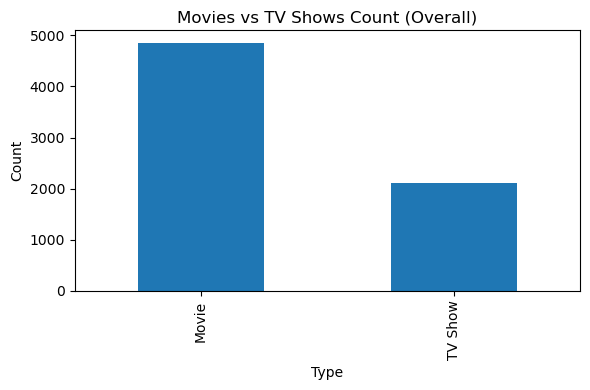

<Figure size 800x400 with 0 Axes>

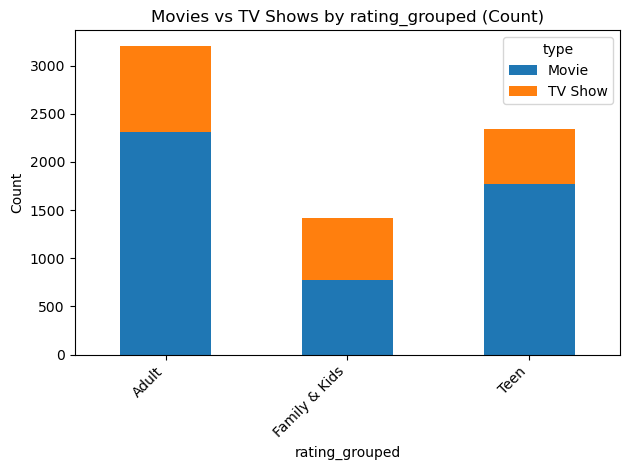

<Figure size 800x400 with 0 Axes>

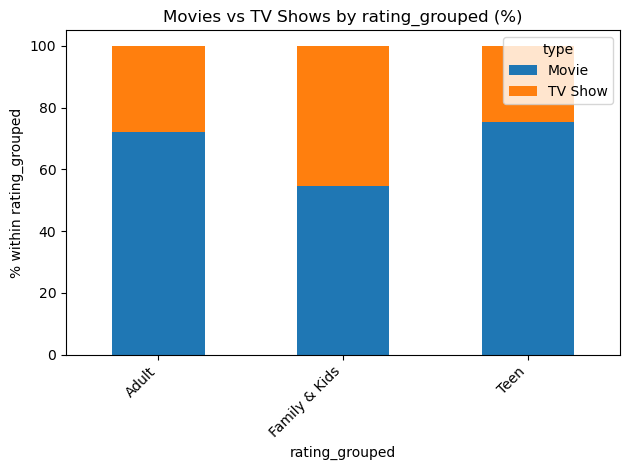

In [46]:
# =========================
# Overall: Count + %
# =========================
type_counts = X_train["type"].value_counts()
type_pct = X_train["type"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
type_counts.plot(kind="bar")
plt.title("Movies vs TV Shows Count (Overall)")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# =========================
# Per rating_grouped: Counts
# =========================
type_by_rating = (
    X_train.groupby("rating_grouped")["type"]
      .value_counts()
      .unstack(fill_value=0)
)

type_by_rating_pct = type_by_rating.div(type_by_rating.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 4))
type_by_rating.plot(kind="bar", stacked=True)
plt.title("Movies vs TV Shows by rating_grouped (Count)")
plt.xlabel("rating_grouped")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
type_by_rating_pct.plot(kind="bar", stacked=True)
plt.title("Movies vs TV Shows by rating_grouped (%)")
plt.xlabel("rating_grouped")
plt.ylabel("% within rating_grouped")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# =========================
# % of each type split across rating groups
# =========================
type_by_rating_col_pct = type_by_rating.div(type_by_rating.sum(axis=0), axis=1) * 100

## Country Column

The number of unique country categories is: 117


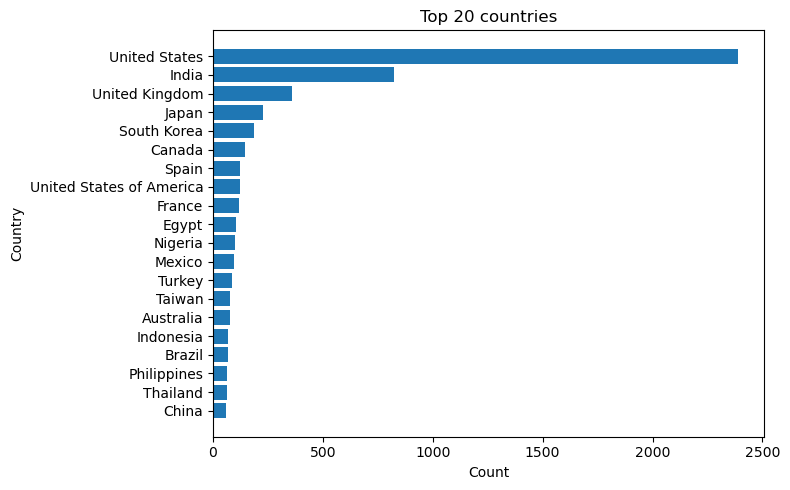

{'New Zealand', 'Mozambique', 'Sweden', 'Croatia', 'Switzerland', 'Malta', 'Finland', 'Russia', 'Nepal', 'Slovenia', 'Argentina', 'Zimbabwe', 'Australia', 'China', 'Philippines', 'Qatar', 'Taiwan', 'Bahamas', 'Algeria', 'Germany', 'Mexico', 'Spain', 'Senegal', 'Denmark', 'Cyprus', 'South Africa', 'Egypt', 'Vatican City', 'United Arab Emirates', 'Portugal', 'Israel', 'Samoa', 'Cuba', 'Jordan', 'Jamaica', 'Romania', 'Nicaragua', 'Liechtenstein', 'Bermuda', 'Cameroon', 'Kenya', 'Syria', 'Austria', 'Angola', 'Paraguay', 'United Kingdom', 'Poland', 'Norway', 'Venezuela', 'Lebanon', 'Indonesia', 'Serbia', 'Singapore', 'Ecuador', 'Saudi Arabia', 'Iceland', 'Colombia', 'Mongolia', 'Montenegro', 'Chile', 'United States of America', 'Peru', 'Uganda', 'Georgia', 'Cayman Islands', 'Nigeria', 'Japan', 'Slovakia', 'United States', 'Palestine', 'Turkey', 'South Korea', 'Ireland', 'West Germany', 'Ukraine', 'Namibia', 'Czech Republic', 'Kuwait', 'Syrian Arab Republic', 'Thailand', 'Hong Kong', 'India'

In [47]:
# Basic categorical plot for "country"
X_train["country"] = X_train["country"].fillna("Unknown").astype(str)

X_train["country_list"] = (
    X_train["country"]
    .astype(str)
    .str.split(",")
    .apply(lambda xs: [x.strip() for x in xs if x.strip()])
)

# 2) How many names per item
X_train["country_count"] = X_train["country_list"].apply(len)
fig1 = df_to_plotly_table(X_train["country_count"].describe(), "Country Count")
fig1.show()


# 2) Overall frequency
country_freq = X_train.explode("country_list")["country_list"].value_counts()

# 3) Count per label for each country
country_by_label = (
    X_train.explode("country_list")
      .groupby(["country_list", "rating_grouped"])
      .size()
      .unstack(fill_value=0)   # columns = labels
)

country_by_label = country_by_label.div(country_freq, axis=0) * 100

# 4) Limit to top N overall and keep the label columns
top_n = 50
country_by_label_top = country_by_label.loc[country_freq.head(top_n).index]
country_by_label_pct_top_fmt = country_by_label_top.map(lambda x: f"{x:.2f}%")
country_by_label_pct_top_fmt['overall'] = country_freq 
fig2 = df_to_plotly_table(country_by_label_pct_top_fmt[:10], 'Country Appearance')
fig2.show()

all_country = set()
X_train["country_list"].apply(lambda x: all_country.update(x))
print(f"The number of unique country categories is: {len(all_country)}")

country_counts = X_train["country"].value_counts().head(20).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(country_counts.index, country_counts.values)
plt.title("Top 20 countries")
plt.xlabel("Count")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

print(all_country)

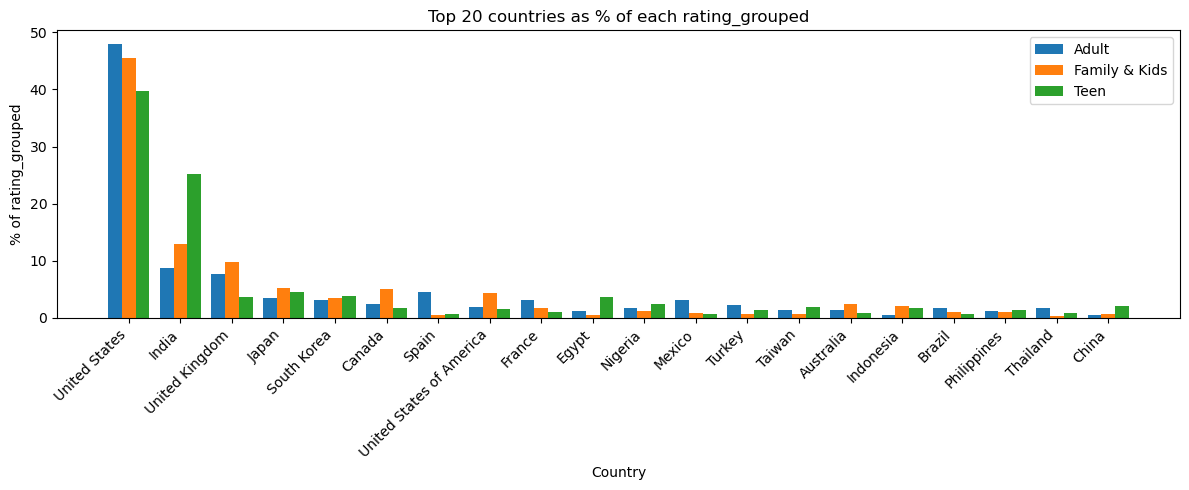

In [48]:
top_n = 20
top_countries = X_train["country"].value_counts().head(top_n).index

# counts table: rows=countries, cols=rating_grouped
country_by_label = (
    X_train[X_train["country"].isin(top_countries)]
      .groupby(["country", "rating_grouped"])
      .size()
      .unstack(fill_value=0)
      .loc[top_countries]
)

# % FROM rating_grouped (column-wise)
country_by_label_pct = country_by_label.div(country_by_label.sum(axis=0), axis=1) * 100

# grouped bar plot
x = np.arange(len(country_by_label_pct.index))
labels = list(country_by_label_pct.columns)
width = 0.8 / max(len(labels), 1)

plt.figure(figsize=(12, 5))
for i, lab in enumerate(labels):
    plt.bar(
        x + i * width - (len(labels) - 1) * width / 2,
        country_by_label_pct[lab].values,
        width,
        label=str(lab)
    )

plt.xticks(x, country_by_label_pct.index, rotation=45, ha="right")
plt.xlabel("Country")
plt.ylabel("% of rating_grouped")
plt.title(f"Top {top_n} countries as % of each rating_grouped")
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
# Merge "United States" - "United States of America" and "Syria" - "Syrian Arab Republic"
# Define the mapping: { "Old Name": "New Standard Name" }
cleanup_map = {
    "United States of America": "United States",
    "Syrian Arab Republic": "Syria"
}

# Apply the replacement to the 'country' column
X_train['country'] = X_train['country'].replace(cleanup_map)

# Optional: Verify the changes
print(X_train['country'].value_counts().head())

country
United States     2510
India              822
United Kingdom     359
Japan              226
South Korea        185
Name: count, dtype: int64


## Description column

In [50]:
X_train["description"] = X_train["description"].fillna("").astype(str)
X_train["char_len"] = X_train["description"].str.len()
X_train["word_len"] = X_train["description"].str.split().apply(len)

fig1 = df_to_plotly_table(X_train[["char_len", 'word_len']].describe(), "Generl Length of Description")
fig1.show()

# Exact duplicates
dupes = X_train[X_train["description"].duplicated(keep=False)].sort_values(by="description")

fig2 = df_to_plotly_table(dupes[['description', 'rating_grouped', 'title']], f"Duplicate rows: {len(dupes)}", include_index=False )
fig2.show()

fig3 = df_to_plotly_table(X_train.groupby("rating_grouped")["word_len"].describe(), "Amount of Words Per Rating")
fig3.show()

In [51]:
# Count duplicates BEFORE removal
num_dupes_before = X_train["description"].duplicated(keep=False).sum()
num_rows_before = len(X_train)

print(f"Duplicate rows (before removal): {num_dupes_before}")
print(f"Total rows before removal: {num_rows_before}")

# Remove duplicate descriptions while keeping the FIRST occurrence
X_train = X_train.drop_duplicates(subset=["description"], keep="first")


num_dupes_after = X_train["description"].duplicated(keep=False).sum()
num_rows_after = len(X_train)

print(f"Duplicate rows (after removal): {num_dupes_after}")
print(f"Total rows after removal: {num_rows_after}")

print(f"Rows removed: {num_rows_before - num_rows_after}")

Duplicate rows (before removal): 28
Total rows before removal: 6967
Duplicate rows (after removal): 0
Total rows after removal: 6953
Rows removed: 14


In [52]:
STOPWORDS = set(ENGLISH_STOP_WORDS)
def tokenize_keep_stopwords(s):
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", " URL ", s)
    s = re.sub(r"[^a-z0-9\s']", " ", s)
    return [t for t in s.split() if t]

tokens_all = X_train["description"].apply(tokenize_keep_stopwords)

X_train["stopword_ratio"] = tokens_all.apply(
    lambda ts: (sum(t in STOPWORDS for t in ts) / max(len(ts), 1))
)

# Simple lexical diversity proxy
X_train["unique_ratio"] = tokens_all.apply(lambda ts: len(set(ts)) / max(len(ts), 1))
fig1 = df_to_plotly_table(X_train.groupby('rating_grouped')["unique_ratio"].describe(), "Unique ratio by label")
fig2 = df_to_plotly_table(X_train.groupby('rating_grouped')["stopword_ratio"].describe(), title="Stopword ratio by label")
fig1.show()
fig2.show()

In [53]:
def simple_tokenize(s):
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", " URL ", s)
    s = re.sub(r"[^a-z0-9\s']", " ", s)
    return [t for t in s.lower().split() if t not in STOPWORDS]

tokens = X_train["description"].apply(simple_tokenize)
all_tokens = [t for row in tokens for t in row]

counter = Counter(all_tokens)
print("Vocab size:", len(counter))
print("Top 20 tokens:", counter.most_common(20))

Vocab size: 17498
Top 20 tokens: [('life', 665), ('young', 587), ('new', 551), ('family', 472), ('s', 431), ('world', 419), ('man', 401), ('love', 397), ('woman', 371), ('friends', 337), ('series', 307), ('documentary', 282), ('old', 266), ('school', 263), ('finds', 252), ('home', 252), ('help', 241), ('high', 234), ('lives', 222), ('takes', 212)]


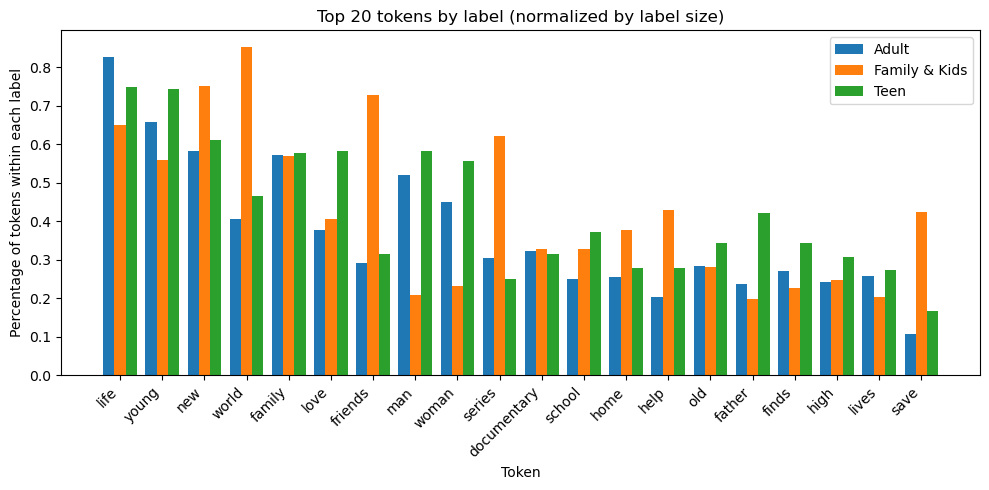

In [54]:
def plot_top_tokens_one_plot_normalized(
    df, text_col="description", label_col="rating_grouped", top_n=20
):
    # Build shared vocab on full corpus
    vec = CountVectorizer(stop_words="english", min_df=2)
    X = vec.fit_transform(df[text_col])
    terms = np.array(vec.get_feature_names_out())

    labels = sorted(df[label_col].dropna().unique())
    label_counts = {}
    label_sizes = df[label_col].value_counts().to_dict()  # number of rows per label

    for lab in labels:
        idx = (df[label_col] == lab).values
        X_lab = X[idx]
        if X_lab.shape[0] == 0:
            continue

        raw_counts = np.asarray(X_lab.sum(axis=0)).ravel()

        # Normalize by label row count -> "tokens per 100 samples of this label"
        n_lab = label_sizes.get(lab, 1)
        norm_counts = (raw_counts / raw_counts.sum()) * 100

        label_counts[lab] = norm_counts

    if not label_counts:
        print("No label token counts found.")
        return

    counts_df = pd.DataFrame(label_counts, index=terms)

    # Pick global top tokens by normalized total across labels
    counts_df["total"] = counts_df.sum(axis=1)
    top = counts_df.sort_values("total", ascending=False).head(top_n).drop(columns=["total"])

    # Grouped bar plot
    x = np.arange(len(top.index))
    n_labels = len(top.columns)
    width = 0.8 / max(n_labels, 1)

    plt.figure(figsize=(10, 5))
    for i, lab in enumerate(top.columns):
        plt.bar(
            x + i * width - (n_labels - 1) * width / 2,
            top[lab].values,
            width,
            label=str(lab),
        )

    plt.xticks(x, top.index, rotation=45, ha="right")
    plt.xlabel("Token")
    plt.ylabel("Percentage of tokens within each label")
    plt.title(f"Top {top_n} tokens by label (normalized by label size)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_top_tokens_one_plot_normalized(X_train, top_n=20)

## Cast column 

In [55]:
# 1) Parse cast into list
X_train["cast_list"] = (
    X_train["cast"]
    .fillna("")
    .astype(str)
    .str.split(",")
    .apply(lambda xs: [x.strip() for x in xs if x.strip()])
)

# 2) How many names per item
X_train["cast_count"] = X_train["cast_list"].apply(len)
fig1 = df_to_plotly_table(X_train["cast_count"].describe(), "Cast Count")
fig1.show()


# 2) Overall frequency
cast_freq = X_train.explode("cast_list")["cast_list"].value_counts()

# 3) Count per label for each cast name
cast_by_label = (
    X_train.explode("cast_list")
      .groupby(["cast_list", "rating_grouped"])
      .size()
      .unstack(fill_value=0)   # columns = labels
)

cast_by_label = cast_by_label.div(cast_freq, axis=0) * 100

# 4) Limit to top N overall and keep the label columns
top_n = 50
cast_by_label_top = cast_by_label.loc[cast_freq.head(top_n).index]
cast_by_label_pct_top_fmt = cast_by_label_top.map(lambda x: f"{x:.2f}%")
cast_by_label_pct_top_fmt['overall'] = cast_freq 
fig2 = df_to_plotly_table(cast_by_label_pct_top_fmt[:10], 'Cast Apearence')
fig2.show()


all_cast = set()
X_train["cast_list"].apply(lambda x: all_cast.update(x))
print(f"The number of unique cast categories is: {len(all_cast)}")

The number of unique cast categories is: 32800


## Listed_in Column

In [56]:
# 1) Parse listed_in into list
X_train["listed_in_list"] = (
    X_train["listed_in"]
    .fillna("")
    .astype(str)
    .str.split(",")
    .apply(lambda xs: [x.strip() for x in xs if x.strip()])
)

# 2) How many categories per item (NEW column)
X_train["listed_in_count"] = X_train["listed_in_list"].apply(len)

fig1 = df_to_plotly_table(X_train["listed_in_count"].describe(), "Listed In Count")
fig1.show()

# 3) Overall frequency 
listed_freq = X_train.explode("listed_in_list")["listed_in_list"].value_counts()

# 4) Count per label
listed_by_label = (
    X_train.explode("listed_in_list")
      .groupby(["listed_in_list", "rating_grouped"])
      .size()
      .unstack(fill_value=0)
)

# 5) Convert to % of overall per category
listed_by_label_pct = listed_by_label.div(listed_freq, axis=0) * 100

# 6) Top N
top_n = 100
top_idx = listed_freq.head(top_n).index
listed_by_label_pct_top = listed_by_label_pct.loc[top_idx]

listed_by_label_pct_top_fmt = listed_by_label_pct_top.map(lambda x: f"{x:.2f}%")

# 7) Add overall column (for % version this is 100)
listed_by_label_pct_top_fmt["overall"] = listed_freq


fig2 = df_to_plotly_table(listed_by_label_pct_top_fmt, "Listed In Appearance (% of overall)")
fig2.show()

all_categories = set()
X_train["listed_in_list"].apply(lambda x: all_categories.update(x))
print(f"The number of unique listed_in categories is: {len(all_categories)}")

The number of unique listed_in categories is: 42


## Director Column

In [57]:
# 1) Parse director into list
X_train["director_list"] = (
    X_train["director"]
    .fillna("")
    .astype(str)
    .str.split(",")
    .apply(lambda xs: [x.strip() for x in xs if x.strip()])
)

# 2) How many directors per item (NEW column)
X_train["director_count"] = X_train["director_list"].apply(len)
extra_p = [0.01, 0.05, 0.10, 0.20, 0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99]

fig1 = df_to_plotly_table(X_train["director_count"].describe(percentiles=extra_p), "Director Count")
fig1.show()

# 3) Overall frequency
director_freq = X_train.explode("director_list")["director_list"].value_counts()

# 4) Count per label for each director
director_by_label = (
    X_train.explode("director_list")
      .groupby(["director_list", "rating_grouped"])
      .size()
      .unstack(fill_value=0)
)

# 5) % of overall per director 
director_by_label_pct = director_by_label.div(director_freq, axis=0) * 100

# 6) Limit to top N overall
top_n = 50
top_idx = director_freq.head(top_n).index
director_by_label_top = director_by_label_pct.loc[top_idx]

# 7) Dormat % 
director_by_label_pct_top_fmt = director_by_label_top.map(lambda x: f"{x:.2f}%")

# 8) add overall raw count (aligned)
director_by_label_pct_top_fmt["overall"] = director_freq.reindex(top_idx).values

# 9) Show
fig2 = df_to_plotly_table(director_by_label_pct_top_fmt.head(20), "Director Appearance")
fig2.show()

all_directors = set()
X_train["director_list"].apply(lambda x: all_directors.update(x))
print(f"The number of unique directores categories is: {len(all_directors)}")

The number of unique directores categories is: 5748


## Release Year Column

Missing/invalid release_year: 0


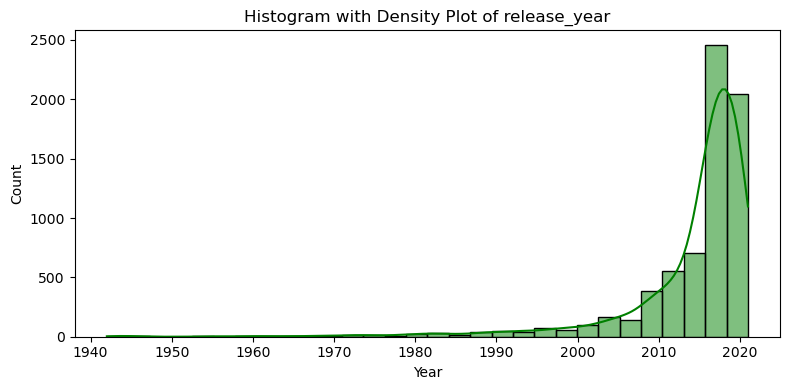

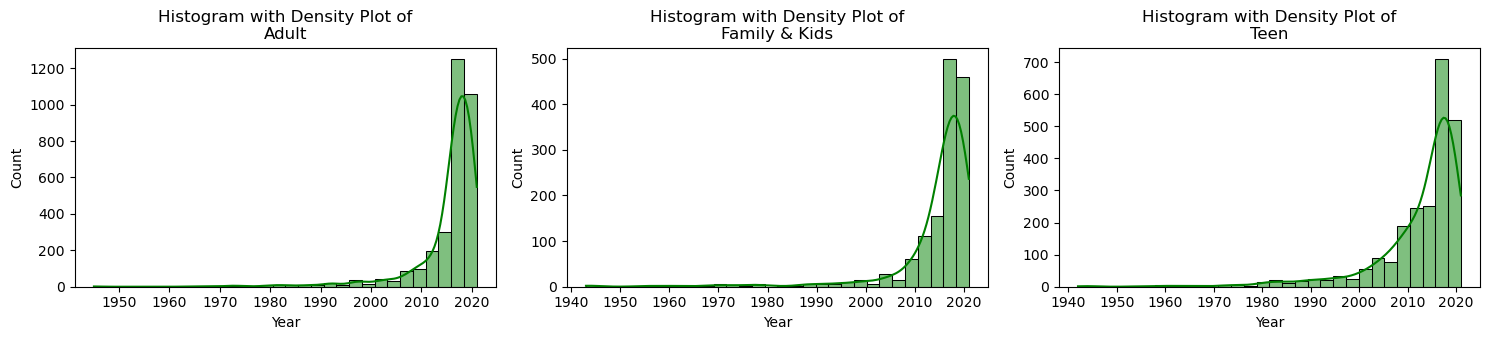

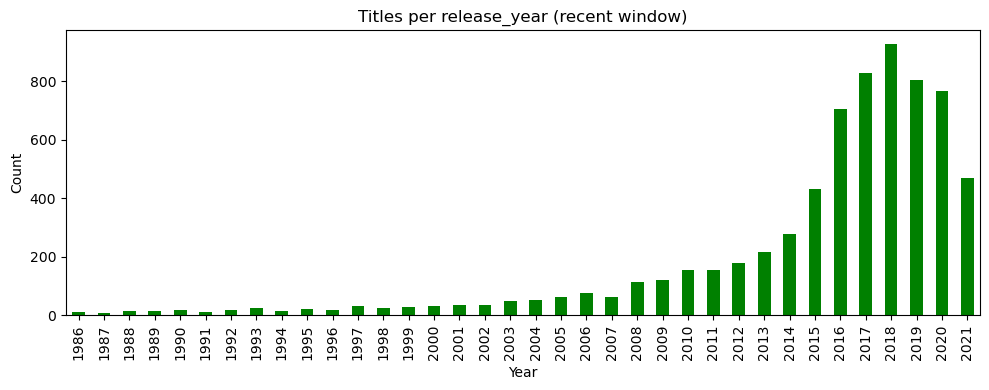

In [58]:
release_col = "release_year"

# Ensure numeric (should already be, but safe)
X_train[release_col] = pd.to_numeric(X_train[release_col], errors="coerce")

# Quick quality check
print(f"Missing/invalid {release_col}:", X_train[release_col].isna().sum())

# 1) Numeric analysis
year_desc = X_train[release_col].describe()

# Plotly table helper 
fig = df_to_plotly_table(year_desc, f"{release_col} Summary")
fig.show()

# 2) Distribution plot (same style: hist + kde, green)
plt.figure(figsize=(8, 4))
sns.histplot(X_train[release_col].dropna(), kde=True, color="green", bins=30)
plt.title(f"Histogram with Density Plot of {release_col}")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3) Analyze by rating_grouped
if "rating_grouped" in X_train.columns:
    # Summary table by label
    by_label = X_train.groupby("rating_grouped")[release_col].describe()
    fig2 = df_to_plotly_table(by_label, f"{release_col} by rating_grouped")
    fig2.show()

    # Hist + KDE per label in subplots
    labels = sorted(X_train["rating_grouped"].dropna().unique())
    n = len(labels)
    n_cols = 3
    n_rows = math.ceil(n / n_cols)

    plt.figure(figsize=(5 * n_cols, 3.5 * n_rows))
    for i, lab in enumerate(labels):
        plt.subplot(n_rows, n_cols, i + 1)
        data = X_train.loc[df["rating_grouped"] == lab, release_col].dropna()
        sns.histplot(data, kde=True, color="green", bins=30)
        plt.title(f"Histogram with Density Plot of\n{lab}")
        plt.xlabel("Year")
        plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

# 4) Simple time-volume trend: titles per release year
yearly = (
    X_train.dropna(subset=[release_col])
      .groupby(release_col)
      .size()
      .sort_index()
)

plt.figure(figsize=(10, 4))

# Show recent years window for readability 
yearly.tail(36).plot(kind="bar", color="green")
plt.title(f"Titles per {release_col} (recent window)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Date_added Column

In [59]:
# Clean the date_added column BEFORE parsing
X_train["date_added"] = (
    X_train["date_added"]
        .astype(str)
        .str.strip()                 # remove leading/trailing spaces
        .str.replace(r'\s+', ' ', regex=True)  # collapse multiple spaces
        .str.replace("-", " ")       # normalize separators
        .str.replace("/", " ")       # normalize separators
)

6222       April 1, 2018
1373    January 27, 2021
6994    November 8, 2018
8144       March 1, 2018
1409    January 15, 2021
Name: date_added, dtype: object
Missing/invalid date_added: 0
First date_added: 2008-01-01 00:00:00


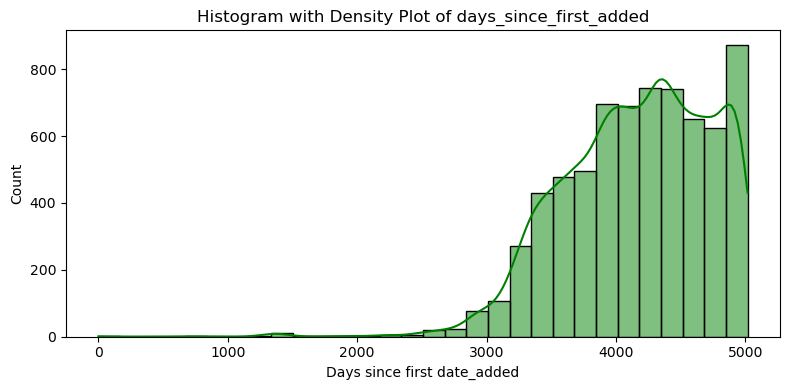

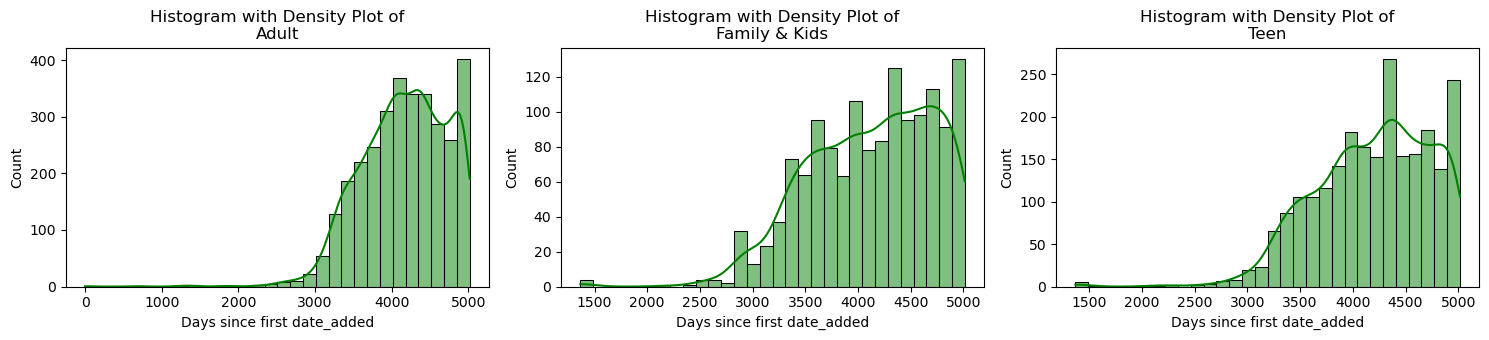

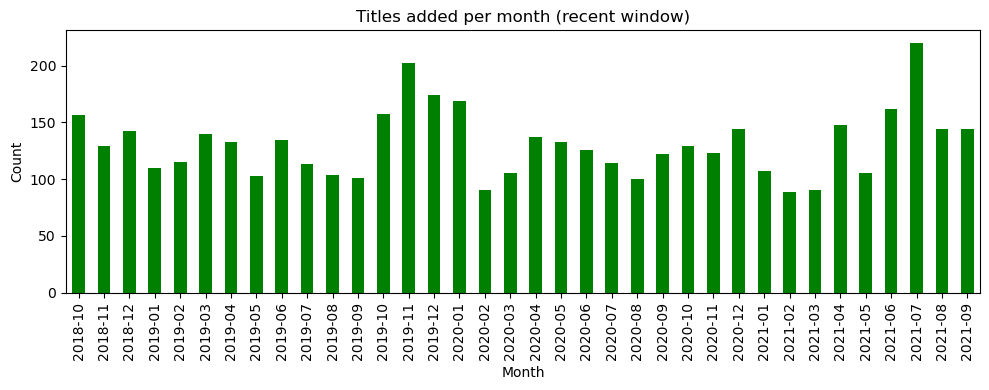

In [60]:
print(X_train["date_added"].head())

# 1) Parse textual dates -> datetime
X_train["date_added_dt"] = pd.to_datetime(X_train["date_added"], errors="coerce")

# Quick quality check
print("Missing/invalid date_added:", X_train["date_added_dt"].isna().sum())

# 2) Find the first (minimum) valid date
train_first_date = X_train["date_added_dt"].min()
print("First date_added:", train_first_date)

# 3) Transform to numeric: days since first date
X_train["days_since_first_added"] = (X_train["date_added_dt"] - train_first_date).dt.days

# 4) Numeric analysis with extra percentiles
days_desc = X_train["days_since_first_added"].describe()

# Plotly table helper (if you already defined it)
fig = df_to_plotly_table(days_desc, "Days Since First date_added")
fig.show()

# 5) Distribution plot 
plt.figure(figsize=(8, 4))
sns.histplot(X_train["days_since_first_added"].dropna(), kde=True, color="green", bins=30)
plt.title("Histogram with Density Plot of days_since_first_added")
plt.xlabel("Days since first date_added")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 6) Analyze by rating_grouped 
if "rating_grouped" in X_train.columns:
    # Summary table by label
    by_label = X_train.groupby("rating_grouped")["days_since_first_added"].describe()
    fig2 = df_to_plotly_table(by_label, "Days Since First by rating_grouped")
    fig2.show()

    # Hist + KDE per label in subplots 
    labels = sorted(X_train["rating_grouped"].dropna().unique())
    n = len(labels)
    n_cols = 3
    n_rows = math.ceil(n / n_cols)

    plt.figure(figsize=(5 * n_cols, 3.5 * n_rows))
    for i, lab in enumerate(labels):
        plt.subplot(n_rows, n_cols, i + 1)
        data = X_train.loc[X_train["rating_grouped"] == lab, "days_since_first_added"].dropna()
        sns.histplot(data, kde=True, color="green", bins=30)
        plt.title(f"Histogram with Density Plot of\n{lab}")
        plt.xlabel("Days since first date_added")
        plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

# 7) Simple time-volume trend
monthly = (
    X_train.dropna(subset=["date_added_dt"])
      .assign(month=X_train["date_added_dt"].dt.to_period("M").astype(str))
      .groupby("month")
      .size()
)

plt.figure(figsize=(10, 4))
monthly.tail(36).plot(kind="bar", color="green")  
plt.title("Titles added per month (recent window)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [61]:
# Calculate Pearson correlation between date_added (numeric) and release_year
correlation, p_value = pearsonr(X_train['days_since_first_added'], X_train['release_year'])

print(f"Pearson Correlation between 'days_since_first_added' and 'release_year':")
print(f"  Correlation coefficient: {correlation:.4f}")
print(f"  P-value: {p_value:.4e}")
print(f"  Interpretation: {'Strong' if abs(correlation) > 0.7 else 'Moderate' if abs(correlation) > 0.4 else 'Weak'} {'positive' if correlation > 0 else 'negative'} correlation")

Pearson Correlation between 'days_since_first_added' and 'release_year':
  Correlation coefficient: 0.1031
  P-value: 6.6159e-18
  Interpretation: Weak positive correlation


## Title Column

In [62]:
# Ensure title is string
X_train["title"] = X_train["title"].fillna("").astype(str)

# Compute lengths
X_train["title_char_len"] = X_train["title"].str.len()
X_train["title_word_len"] = X_train["title"].str.split().apply(len)

# Visualize summary statistics for title lengths
fig_title_stats = df_to_plotly_table(
    X_train[["title_char_len", "title_word_len"]].describe(),
    "General Length Statistics of Titles"
).show()

# Detect exact duplicate titles
title_dupes = (
    X_train[X_train["title"].duplicated(keep=False)]
    .sort_values("title")
)

# Visualize duplicate titles
fig_title_dupes = df_to_plotly_table(
    title_dupes[['title', 'rating_grouped', 'description']],
    f"Duplicate Title Rows: {len(title_dupes)}",
    include_index=False
).show()

fig3 = df_to_plotly_table(X_train.groupby("rating_grouped")["title_word_len"].describe(), "Amount of Words in Title Per Rating")
fig3.show()

# Baseline Model

As to have a complete unbiased true baseline model, we will use only the original dataset features and represent all text columns using TF–IDF, type (Movie/TV Show) using One-Hot Encoding and keep the only numeric field "release_year" as is.
So in total our baseline feature set will be:

| Column       | Type        | Baseline Representation   |
| ------------ | ----------- | ------------------------- |
| type         | Categorical | One-hot (Movie/TV Show)   |
| title        | Text        | TF–IDF                    |
| director     | Text        | TF–IDF                    |
| cast         | Text        | TF–IDF                    |
| country      | Text        | TF–IDF                    |
| date_added   | Date        | Took days_since_first_added (numeric)
| release_year | Numeric     | Keep as integer           |
| duration     | Text        | TF–IDF                    |
| listed_in    | Text        | TF–IDF                    |
| description  | Text        | TF–IDF                    |
| show_id      | Identifier  | ❌ DROP                    |
| rating_label | Target      | 0,1,2                     |


We are not using extra features from the EDA because they are engineered, hence will increase accuracy artificially and bias future comparisons as they create dependency between EDA and modeling

For a baseline, the only features we should use are:

✔ Raw dataset columns
✔ Minimal transformations (TF–IDF, OHE)
✔ Minimal preprocessing (fill missing, etc.)


Even though by applying this for our basline model, meaning we will have thousands of TF–IDF features, that is perfectly fine.

Later more advanced models (e.g, XGBoost) will compress, learn structure, and perform better, as we will apply dimensionality reduction and smarter embeddings techniques.

## Apply simple TF-IDF Embeddings per Text Column

This way each feature contributes independently

In [63]:
# Define the feature groups 
text_features = [
    "title",
    "director",
    "cast",
    "country",
    "duration",
    "listed_in",
    "description"
]

categorical_features = ["type"]
numeric_features = ["release_year", "days_since_first_added"]

# Build the ColumnTransformer - Each text column gets its own TF–IDF vectorizer
preprocessor = ColumnTransformer(
    transformers=[
        # Separate TF-IDF for each text column
        *[
            (f"tfidf_{col}", 
             TfidfVectorizer(
                 stop_words="english",
                 max_features=5000  # limit for baseline simplicity
             ),
             col)
            for col in text_features
        ],
        
        # OneHot for type (Movie / TV Show)
        ("ohe_type", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        
        # Passthrough numeric
        ("num", "passthrough", numeric_features),
    ],
    remainder="drop"
)

Whenever we drop rows from X_train, we must also drop the same rows from y_train, otherwise we’ll get: ValueError: Found input variables with inconsistent numbers of samples

In [64]:
# Align y_train to the rows kept in X_train
y_train = y_train.loc[X_train.index]

## Baseline Model - Logistic Regression

In [65]:
# Build the Baseline Model Pipeline
baseline_model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        max_iter=3000,
        multi_class="multinomial",
        n_jobs=-1
    ))
])

# Fit the Model
baseline_model.fit(X_train, y_train)

c:\Users\Public\Documents\Python Scripts\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tfidf_title', ...), ('tfidf_director', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
X_train_transformed = baseline_model.named_steps["preprocess"].transform(X_train)
n_features = X_train_transformed.shape[1]
print(f"Total number of features after preprocessing: {n_features}")

Total number of features after preprocessing: 20372


## Preprocessing the test data like the train data

To ensure no train-test leakage we must preprocess the test set using the exact same steps as the training set, in the same order, with the same logic, using the same values learned from training (e.g., most common country, same imputation, same text cleaning). This includes:
    
1) TMDb enrichment
    
2) Country mode imputation (using mode from train)
    
3) Fill director/cast with "Unknown"
   
4) Clean date_added
  
5) Remove rows with missing date_added
    
6) Remove rows with duplicate descriptions

7) Embedd the data the same way as in train

In [67]:
def preprocess_test_data(
    df,
    country_mode,
    train_first_date,
    tmdb_cache_path="tmdb_cache.json"
):
    """
    Preprocess test data using the same steps as train:
    - TMDb enrichment
    - Country mode imputation (learned from train)
    - Fill director/cast with 'Unknown'
    - Clean date_added and convert to datetime
    - Drop missing date_added rows
    - Remove duplicate descriptions
    - Ensure proper dtypes
    """

    """
    Preprocess test data using the EXACT same steps as the training set:
    - TMDb enrichment via shared cache
    - Country mode imputation (from training)
    - Fill director/cast with 'Unknown'
    - Clean date_added text 
    - Remove duplicate descriptions
    - Ensure consistent string formats for text features
    - Prepare 'type' column for OHE
    """

    df = df.copy()

    # ======================================================
    # 1. TMDb enrichment (use same cache to avoid re-calls)
    # ======================================================
    df = enrich_with_tmdb(df, cache_path=tmdb_cache_path)

    # ======================================================
    # 2. Impute country using mode FROM TRAIN
    # ======================================================
    df["country"] = df["country"].fillna(country_mode)

    # ------------------------------------------------------
    # 3. Standardize Country Names (Match Train)
    # ------------------------------------------------------
    cleanup_map = {
        "United States of America": "United States",
        "Syrian Arab Republic": "Syria"
    }
    df['country'] = df['country'].replace(cleanup_map)


    # ======================================================
    # 4. Fill cast/director with "Unknown"
    # ======================================================
    df["cast"] = df["cast"].fillna("Unknown")
    df["director"] = df["director"].fillna("Unknown")

    # ======================================================
    # 5. Clean date_added
    # ======================================================
    df["date_added"] = (
        df["date_added"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace("-", " ")
        .str.replace("/", " ")
    )

    df["date_added_dt"] = pd.to_datetime(df["date_added"], errors="coerce")

    # ❗ Drop rows with invalid dates (same policy as train)
    df = df.dropna(subset=["date_added_dt"])

    # ✅ Create numeric time feature (CRITICAL FIX)
    df["days_since_first_added"] = (
        df["date_added_dt"] - train_first_date
    ).dt.days

    # ======================================================
    # 6. Remove duplicate descriptions 
    # ======================================================
    df = df.drop_duplicates(subset=["description"], keep="first")

    # ======================================================
    # 7. Ensure all text columns remain text (string) for TF-IDF
    # ======================================================
    text_columns = [
        "title", "director", "cast", "country",
        "date_added", "duration", "listed_in", "description"
    ]

    for col in text_columns:
        df[col] = df[col].fillna("").astype(str)

    # ======================================================
    # 8. Ensure type is clean for OHE in the model pipeline
    # ======================================================
    df["type"] = df["type"].fillna("Unknown").astype(str)

    return df

In [68]:
# Apply the Preprocessing to the Test Set
X_test_preprocessed = preprocess_test_data(
    X_test,
    country_mode=train_country_mode,       # use mode from training
    train_first_date=train_first_date,     # use first date from train
    tmdb_cache_path="tmdb_cache.json"
)

Rows with at least one missing [director/cast/country]: 711
Cache currently has 3446 entries.


C:\Users\עידן שכטר\AppData\Local\Temp\ipykernel_50348\2487003707.py:31: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\עידן שכטר\AppData\Local\Temp\ipykernel_50348\2487003707.py:33: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\עידן שכטר\AppData\Local\Temp\ipykernel_50348\2487003707.py:35: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Total new TMDb API calls made in this run: 0


Whenever we drop rows from X_test, we must also drop the same rows from y_test, otherwise we’ll get: ValueError: Found input variables with inconsistent numbers of samples

In [69]:
# Align y_test to the rows kept in X_test_preprocessed
y_test = y_test.loc[X_test_preprocessed.index]

After preprocessing X_test once, we will save it as a different csv, mostly because the TMDb API is slow and the enrichment results are deterministic with the same cache file. Once preprocessed, running inference later should be instant. This avoids accidentally modifying the test set differently in future runs (ensures reproducibility).

In [70]:
X_test_preprocessed.to_csv("X_test_preprocessed.csv", index=True)

## Evaluation Function

In [71]:
def evaluate_multiclass_classifier(
    y_true,
    y_pred,
    y_proba=None,
    class_names=None,
    title_prefix="Model"
):
    """
    Compute and display multiclass metrics:
    - Accuracy
    - Precision/Recall/F1 per class
    - Macro & weighted averages
    - Confusion matrix (heatmap)
    - ROC curves (one-vs-rest) and macro AUC if y_proba is given.
    
    Parameters
    ----------
    y_true : array-like, shape (n_samples,)
        True labels.
    y_pred : array-like, shape (n_samples,)
        Predicted labels.
    y_proba : array-like, shape (n_samples, n_classes), optional
        Predicted probabilities for each class (for ROC curves).
    class_names : list of str, optional
        Names for each class, in order [0, 1, 2, ...].
    title_prefix : str
        Prefix for plot titles.
    """
    if class_names is None:
        class_names = [str(c) for c in sorted(np.unique(y_true))]
    
    print(f"\n{title_prefix} - Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
    
    # Detailed per-class metrics
    print(f"{title_prefix} - Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{title_prefix} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    
    # ROC curves: only if we have probabilities
    if y_proba is not None:
        n_classes = y_proba.shape[1]
        
        # Binarize true labels for one-vs-rest ROC
        y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
        
        plt.figure(figsize=(7, 5))
        aucs = []
        
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
            auc = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
            aucs.append(auc)
            plt.plot(fpr, tpr, label=f"Class {class_names[i]} (AUC = {auc:.3f})")
        
        # Chance line
        plt.plot([0, 1], [0, 1], "k--", label="Chance")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{title_prefix} - One-vs-Rest ROC Curves")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        print(f"{title_prefix} - Mean AUC across classes: {np.mean(aucs):.4f}")

## Predictions & Evaluation


Baseline Logistic Regression (TF-IDF per feature) - Overall Accuracy: 0.6502

Baseline Logistic Regression (TF-IDF per feature) - Classification Report:

               precision    recall  f1-score   support

Family & Kids       0.72      0.64      0.67       351
         Teen       0.55      0.50      0.52       585
        Adult       0.68      0.77      0.72       802

     accuracy                           0.65      1738
    macro avg       0.65      0.63      0.64      1738
 weighted avg       0.65      0.65      0.65      1738



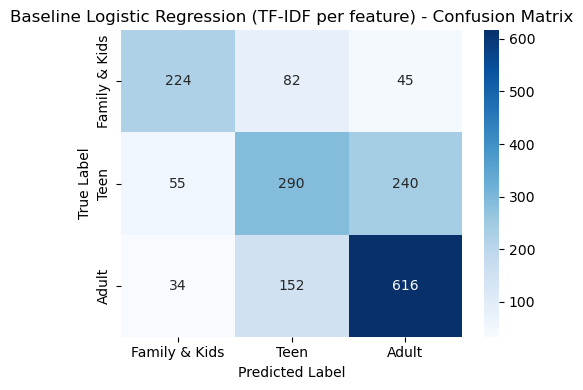

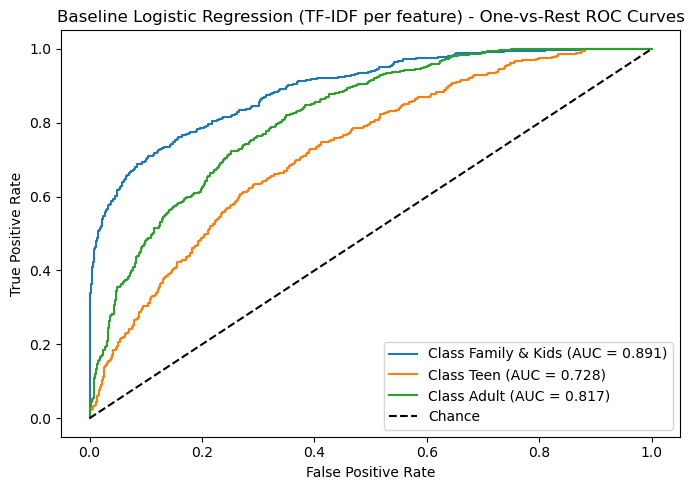

Baseline Logistic Regression (TF-IDF per feature) - Mean AUC across classes: 0.8120


In [72]:
y_pred = baseline_model.predict(X_test_preprocessed)
y_proba = baseline_model.predict_proba(X_test_preprocessed)

class_names = ['Family & Kids', 'Teen', 'Adult']

evaluate_multiclass_classifier(
    y_true=y_test,
    y_pred=y_pred,
    y_proba=y_proba,
    class_names=class_names,
    title_prefix="Baseline Logistic Regression (TF-IDF per feature)"
)


# Elapsed Time

In [73]:
# End the timer
end_time = time.time()

# Calculate the elapsed time
elapsed_time = end_time - start_time

# Convert elapsed time to minutes
elapsed_time_minutes = elapsed_time / 60

# Print the elapsed time in a readable format
print(f"The elapsed time is: {elapsed_time_minutes:.2f} minutes")

The elapsed time is: 0.68 minutes


# TODO
1. Do EDA and fill missing values (for all features)
2. baseline model - text columns with tf-idf model (later LLM  model) and simple one-hot encoding and engineering
3. feature engineering (for all features)

Missing values

| Feature  | None values | handeling method |
| ------ | -------- | -------- |
|director |       2634|Web scraping |
|country  |        831|Leave first and and fill common|
|cast     |        825|Flag with None for now|
|date_added|        10 |Delete rows|
|rating             4|Delete rows|
|duration  |         3|Delete rows|

Feature Engineering Method

| Feature  | Feature Engineering |
| ------ | -------- |
|director |  embedding |
|country  |   one-hot encoding?|
|cast     |        embedding|
|date_added|        int -> Norm |
|duration  | Delete|
|show_id |           Delete| 
|type    |         one-hot encoding|
|title   |          embedding|
|release_year |      Norm|
|listed_in    |      one-hot encoding|
|description   |     embedding|